In [6]:
%pip install geopy
#% pip install --upgrade matplotlib
#% pip install basemap

Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%` not found.


In [7]:
import urllib.request
import json
import pymongo
import pandas as pd
import datetime
import geopy
import warnings
warnings.simplefilter('ignore')

In [8]:
# get the bbc rss feed of news stories and connect to it
earthquake_url = "http://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/significant_month.geojson"

def load_earthquakes():
    try:
        response = urllib.request.urlopen(earthquake_url)
    except urllib.error.URLError as e:
        if hasattr(e, 'reason'):
            print('We failed to reach a server.')
            print('Reason: ', e.reason)
        elif hasattr(e, 'code'):
            print('The server couldn\'t fulfill the request.')
            print('Error code: ', e.code)
    else:
        # the url request was successful - convert the response to a string
        json_string = response.read().decode('utf-8')

        # the json package loads() converts the string to python dictionaries and lists
        eq_json = json.loads(json_string)

        # from the json dictionary we get the title to print
        title = eq_json['metadata']['title']
        print('Collected data from', title)
        #  and we get the list of earthquakes
        quake_list = eq_json['features']
        return quake_list

def get_earthquakes():
        quakelist = load_earthquakes()
        
        quake_docs = []
        for doc in quakelist:
            place = doc["properties"]["place"]
            # grab unix timestamp in milliseconds
            unix_time_mil = doc["properties"]["time"]            
            # convert to unix in seconds
            unix_time = unix_time_mil / 1000
            unix_time = datetime.datetime.fromtimestamp(unix_time).isoformat()
            coords = doc["geometry"]["coordinates"]
            lng, lat, _ = coords
            quake_docs.append([place,unix_time,lat,lng])

        quake_df = pd.DataFrame(quake_docs,columns = ['place','date','latitude','longitude'])
        
        return quake_df

In [9]:
earth_quakes = get_earthquakes()
print(earth_quakes)

Collected data from USGS Significant Earthquakes, Past Month
                                            place                        date  \
0          10 km NNE of Chiautla de Tapia, Mexico  2023-12-07T15:03:38.206000   
1                    123 km S of Isangel, Vanuatu  2023-12-07T07:56:30.660000   
2                    13 km SSE of Volcano, Hawaii  2023-12-04T22:53:46.010000   
3             34 km ENE of Aras-asan, Philippines  2023-12-03T14:49:36.868000   
4              43 km ENE of Hinatuan, Philippines  2023-12-03T05:35:57.353000   
5              47 km NE of Barcelona, Philippines  2023-12-02T11:03:43.974000   
6                           Mindanao, Philippines  2023-12-02T09:37:03.945000   
7                10 km ENE of Rāmganj, Bangladesh  2023-12-01T22:35:32.303000   
8                         11 km E of Ocotillo, CA  2023-12-01T02:43:27.480000   
9                53 km NNE of Petersville, Alaska  2023-12-01T00:50:26.290000   
10             45 km E of Wewak, Papua New Guine

In [10]:
import os

# this solves a bug with the asemap installation
os.environ['PROJ_LIB'] = 'c:/Users/gregb/Anaconda3/pkgs/proj4-5.2.0-ha925a31_1/Library/share'

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

ModuleNotFoundError: No module named 'mpl_toolkits.basemap'

In [ ]:
# let's test the basemap installation
plt.figure(figsize=(8, 8))
m = Basemap(projection='ortho', resolution=None, lat_0=50, lon_0=-100)
m.bluemarble(scale=0.5);

NameError: name 'Basemap' is not defined

<Figure size 800x800 with 0 Axes>

In [ ]:
# let's test the map with basi lat/longs
fig = plt.figure(figsize=(8, 8))
m = Basemap(projection='lcc', resolution=None, width=8E6, height=8E6, lat_0=45, lon_0=-100,)
m.etopo(scale=0.5, alpha=0.5)

# Map (long, lat) to (x, y) for plotting

# 43.03474° N, -76.13881° E
x, y = m(-76.13881, 43.03474)
plt.plot(x, y, 'ok', markersize=5)
plt.text(x, y, ' Syracuse, NY', fontsize=12);

NameError: name 'Basemap' is not defined

<Figure size 800x800 with 0 Axes>

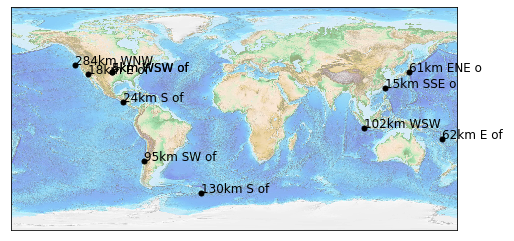

In [ ]:
# let's test the map with basi lat/longs
fig = plt.figure(figsize=(8, 8))
m = Basemap()
m.etopo(scale=0.5, alpha=0.5)

def plot_earthquake(r,row):
    x,y=m(row['longitude'],row['latitude'])
    plt.plot(x,y, 'ok', markersize=5)
    plt.text(x,y, row['place'][0:10], fontsize=12)
    
rc=earth_quakes.apply(lambda row: plot_earthquake(m,row), axis=1)
